In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv('data_multiomics_merged.csv')
print(f"黄金数据集加载成功！总样本数：{df.shape[0]}，总特征数：{df.shape[1]}")

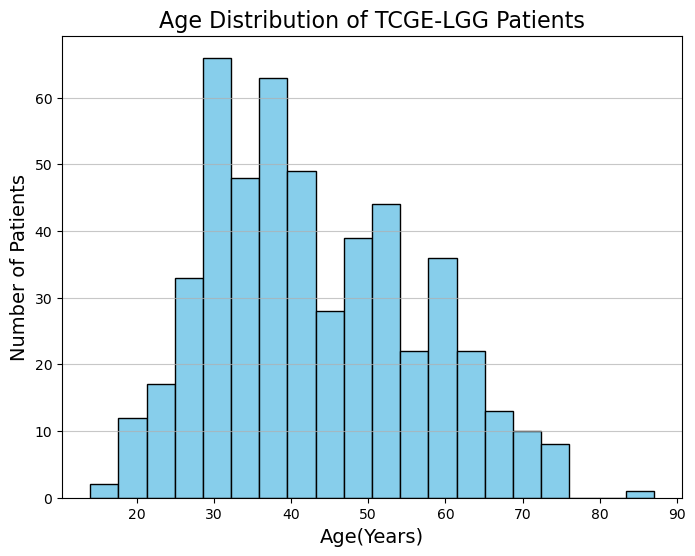

In [2]:
plt.figure(figsize=(8,6))
plt.hist(df['AGE'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution of TCGE-LGG Patients', fontsize=16)
plt.xlabel('Age(Years)', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.grid(axis='y', alpha=0.7)
plt.show()

各分级具体人数：
 GRADE
G3    264
G2    248
Name: count, dtype: int64


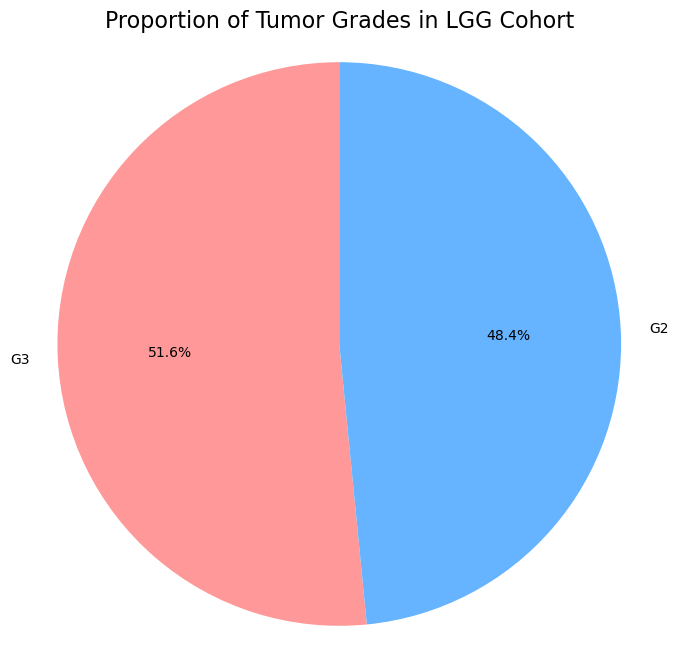

In [3]:
grade_counts = df['GRADE'].value_counts()
print("各分级具体人数：\n", grade_counts)
plt.figure(figsize=(8,8))
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Proportion of Tumor Grades in LGG Cohort', fontsize=16)
plt.axis('equal')
plt.show()


C:\Users\13394\AppData\Local\Temp\ipykernel_25552\3128275729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GRADE', y='TP53', data=df, palette='Set2', showfliers=False)


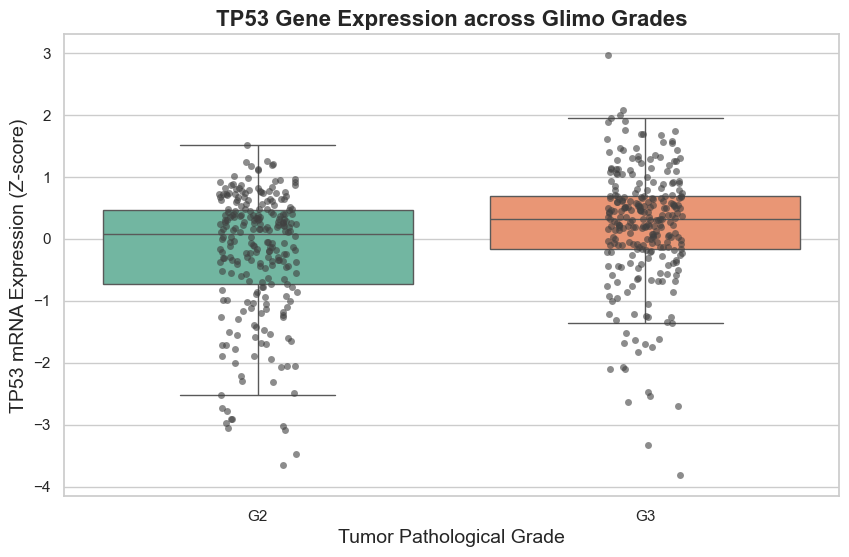

In [7]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
ax = sns.boxplot(x='GRADE', y='TP53', data=df, palette='Set2', showfliers=False)
sns.stripplot(x='GRADE', y='TP53', data=df, color='.25', alpha=0.6, jitter=True)
plt.title('TP53 Gene Expression across Glimo Grades', fontsize=16, fontweight='bold')
plt.xlabel('Tumor Pathological Grade', fontsize=14)
plt.ylabel('TP53 mRNA Expression (Z-score)', fontsize=14)
plt.show()

C:\Users\13394\AppData\Local\Temp\ipykernel_6640\1961977881.py:6: DtypeWarning: Columns (29,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_multiomics_merged.csv")


提纯完成！成功从大表中剥离了临床元数据。
当前纯基因矩阵的维度为：514 样本 x 20518 基因
成功筛选 Top 1000 高方差基因，准备进入 PCA 降维...
降维完成！
PC1 解释了 20.86% 的整体数据差异
PC2 解释了 4.12% 的整体数据差异


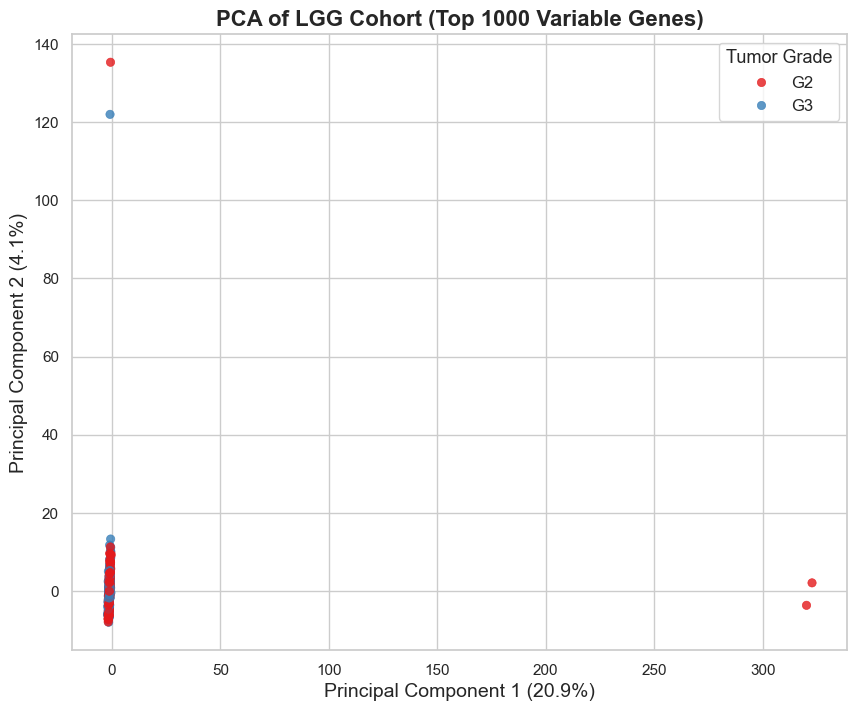

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
df = pd.read_csv("data_multiomics_merged.csv")
patient_cols = pd.read_csv("data_clinical_patient.txt", sep="\t", comment="#", nrows=0).columns.tolist()
sample_cols = pd.read_csv("data_clinical_sample.txt", sep="\t", comment="#", nrows=0).columns.tolist()
all_clinical_cols = set(patient_cols + sample_cols)
gene_cols = [col for col in df.columns if col not in all_clinical_cols]
X_genes = df[gene_cols]
print(f"提纯完成！成功从大表中剥离了临床元数据。")
print(f"当前纯基因矩阵的维度为：{X_genes.shape[0]} 样本 x {X_genes.shape[1]} 基因")
gene_variances = X_genes.var()
top_1000_genes = gene_variances.nlargest(1000).index
X_top1000 = X_genes[top_1000_genes]
print(f"成功筛选 Top 1000 高方差基因，准备进入 PCA 降维...")
pca = PCA(n_components=2)
# 对高维基因矩阵进行拟合与降维转换
X_pca = pca.fit_transform(X_top1000)
# 提取“解释方差比（Explained Variance Ratio）”
# 这代表压缩后的两个维度保留了原始数据多少的信息量
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
print(f"降维完成！")
print(f"PC1 解释了 {pc1_var:.2f}% 的整体数据差异")
print(f"PC2 解释了 {pc2_var:.2f}% 的整体数据差异")
# 将降维后的坐标写回原始的 dataframe，方便结合临床信息画图
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
# 开始画图
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
# 画散点图，hue='GRADE' 意味着根据肿瘤分级涂上不同的颜色
sns.scatterplot(x='PC1', y='PC2', hue='GRADE',data=df, palette='Set1', alpha=0.8, edgecolor=None)
# 加上学术标题和带方差贡献率的坐标轴标签
plt.title("PCA of LGG Cohort (Top 1000 Variable Genes)", fontsize=16, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({pc1_var:.1f}%)", fontsize=14)
plt.ylabel(f"Principal Component 2 ({pc2_var:.1f}%)", fontsize=14)
# 优化图例
plt.legend(title='Tumor Grade', title_fontsize='13', fontsize='12')
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
def perform_umap_analysis(data, labels):
    """
    对高维基因表达数据进行 UMAP 降维并可视化
    """
    # 1. 标准化数据 (标准化对于距离计算非常重要)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # 2. 初始化并运行 UMAP
    # n_neighbors 控制局部与全局结构的平衡，n_components=2 用于画图
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding = reducer.fit_transform(data_scaled)
    
    # 3. 将结果转化为 DataFrame 以便绘图
    umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    umap_df['Label'] = labels
    
    # 4. 可视化
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x='UMAP1', 
        y='UMAP2', 
        hue='Label', 
        palette={'红色组': '#E63946', '蓝色组': '#457B9D'},
        data=umap_df, 
        s=60, 
        alpha=0.8
    )
    
    plt.title('UMAP 基因表达数据分布图', fontsize=15)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='组别')
    plt.tight_layout()
    plt.show()